# Лабораторная работа 5

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


order_items = pd.read_csv("/content/olist_order_items_dataset.csv")
orders = pd.read_csv('/content/olist_orders_dataset.csv')
customers = pd.read_csv('/content/olist_customers_dataset.csv')
order_reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
price = order_items['price']
fr_value = order_items['freight_value']

delivery_data = pd.read_csv('/content/drive/MyDrive/delivery_data.csv')

customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


# Задание 1

In [ ]:
'''Hexbin & KDE: Используйте sns.jointplot, чтобы изучить связь
price и freight_value. Вместо стандартных точек (scatter) используйте
kind='hex' (гексагональная сетка) или kind='kde' (линии уровня плотности).'''

plot_data = pd.DataFrame({
    'price': price,
    'freight_value': fr_value
})

plot_data = plot_data.dropna()
plot_data['log_price'] = np.log1p(plot_data['price'])
plot_data['log_freight'] = np.log1p(plot_data['freight_value'])

plot_data

,price,freight_value,log_price,log_freight
0,58.90,13.29,4.092677,2.659560
1,239.90,19.93,5.484382,3.041184
2,199.00,17.87,5.298317,2.937573
3,12.99,12.79,2.638343,2.623944
4,199.90,18.14,5.302807,2.951780
...,...,...,...,...
112645,299.99,43.41,5.707077,3.793465
112646,350.00,36.53,5.860786,3.625141
112647,99.90,16.95,4.614130,2.887590
112648,55.99,8.72,4.042876,2.274186


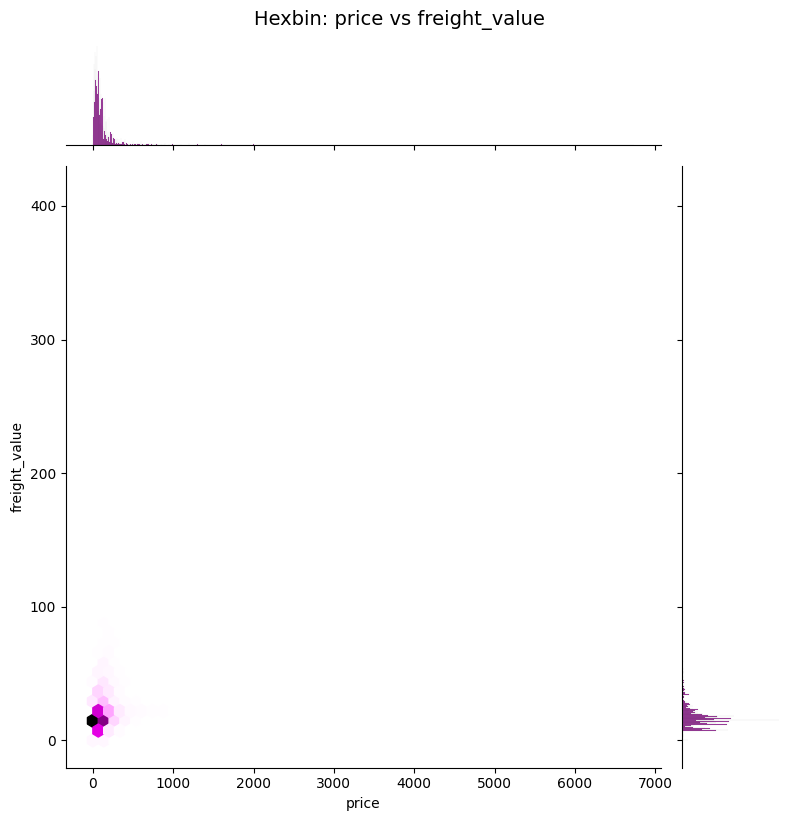

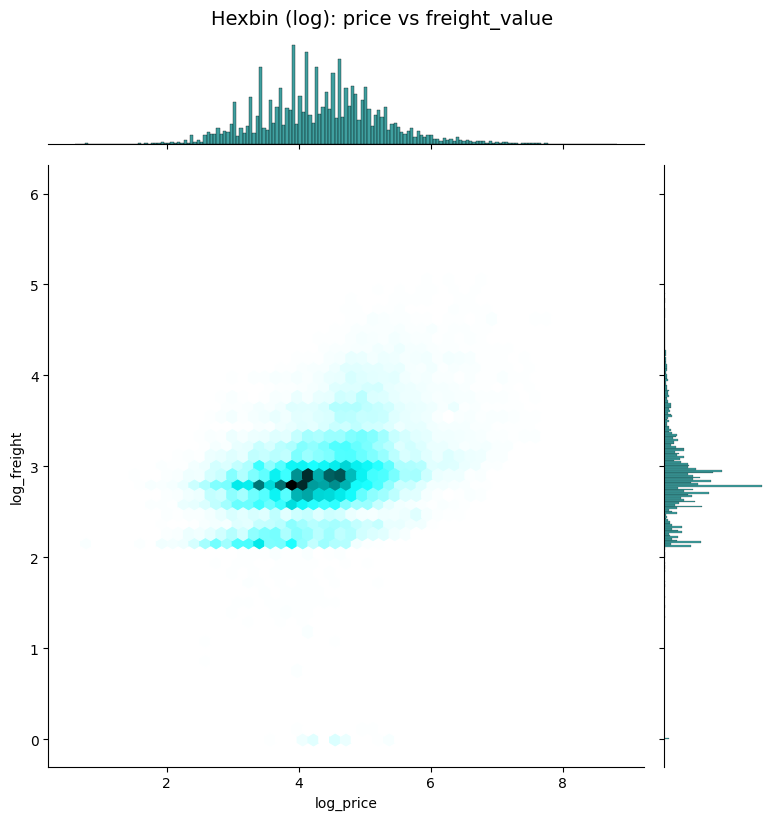

In [ ]:
sns.jointplot(
    data=plot_data,
    x='price',
    y='freight_value',
    kind='hex',
    height=8,
    color='purple'
)

plt.suptitle(
    'Hexbin: price vs freight_value',
    y=1.02,
    fontsize=14
)


sns.jointplot(
    data=plot_data,
    x='log_price',
    y='log_freight',
    kind='hex',
    height=8,
    color='teal'
)

plt.suptitle(
    'Hexbin (log): price vs freight_value',
    y=1.02,
    fontsize=14
)
plt.show()

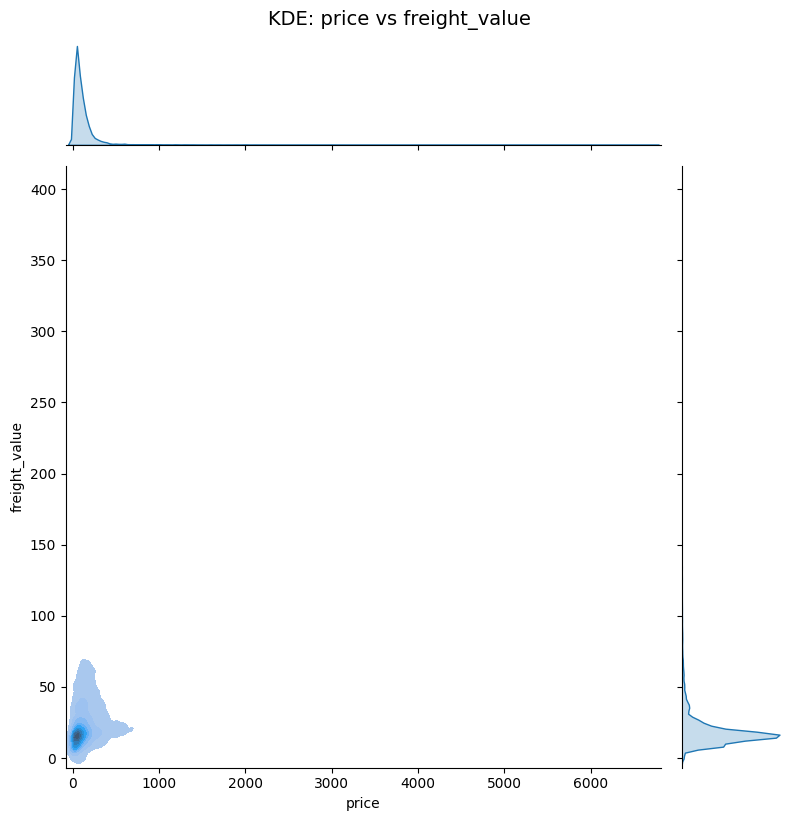

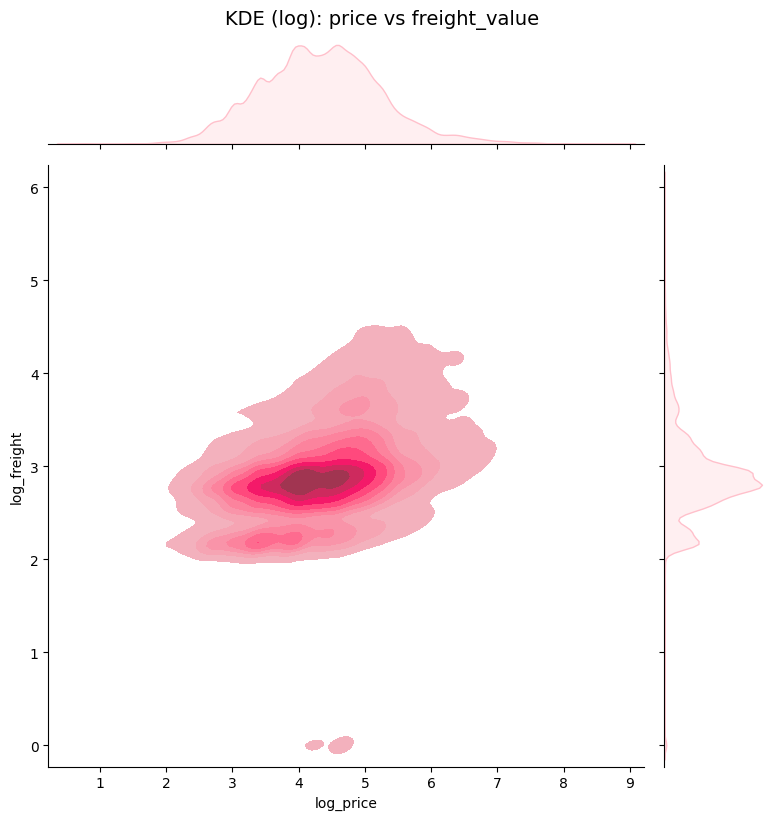

In [ ]:
sns.jointplot(
    data=plot_data,
    x='price',
    y='freight_value',
    kind='kde',
    fill=True,
    height=8
)

plt.suptitle(
    'KDE: price vs freight_value',
    y=1.02,
    fontsize=14
)

sns.jointplot(
    data=plot_data,
    x='log_price',
    y='log_freight',
    kind='kde',
    fill=True,
    height=8,
    color='pink'
)

plt.suptitle(
    'KDE (log): price vs freight_value',
    y=1.02,
    fontsize=14
)


plt.show()

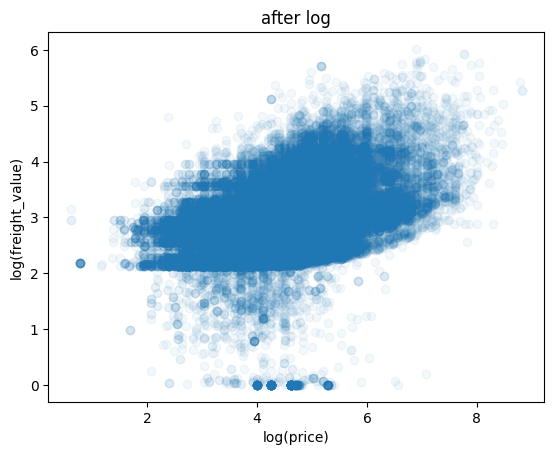

In [ ]:
plt.scatter(
    plot_data['log_price'],
    plot_data['log_freight'],
    alpha=0.05
)

plt.title('after log')

plt.xlabel('log(price)')
plt.ylabel('log(freight_value)')

plt.show()

In [ ]:
delivery_data = delivery_data[delivery_data['delivery_time_working_days'].notna()]
delivery_data = delivery_data.merge(customers,
    on='customer_id',
    how='left'
)
delivery_data

,order_id,customer_id,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_working_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,6.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,7.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,10.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,3.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...
96457,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6.0,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
96458,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,16.0,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
96459,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,18.0,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
96460,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,13.0,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


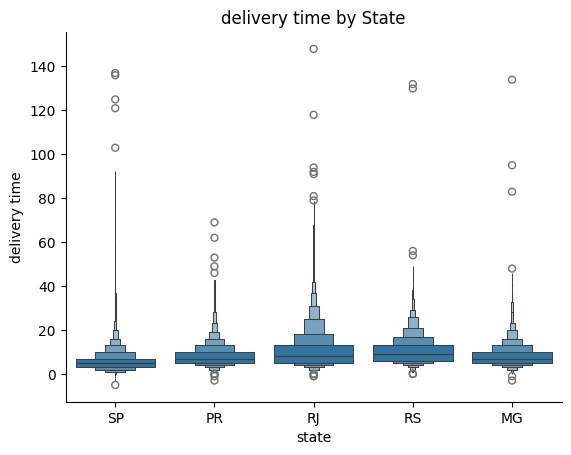

In [ ]:
top_states = delivery_data['customer_state'].value_counts().head(5).index

state_data = delivery_data[delivery_data['customer_state'].isin(top_states)]


sns.boxenplot(
    data=state_data,
    x='customer_state',
    y='delivery_time_working_days'
)

plt.title('delivery time by State')

plt.xlabel('state')
plt.ylabel('delivery time')

sns.despine()

plt.show()

# Задание 2

In [ ]:
cohort_matrix = pd.read_csv('/content/drive/MyDrive/cohort_matrix.csv')
cohort_matrix

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
0,7559.0,25.0,27.0,21.0,23.0,12.0,15.0,17.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
1,7916.0,25.0,30.0,21.0,23.0,16.0,17.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN
2,9277.0,38.0,29.0,30.0,17.0,12.0,4.0,8.0,8.0,2.0,9.0,3.0,5.0,3.0,4.0,6.0,2.0,3.0,NaN,NaN
3,8838.0,53.0,25.0,20.0,15.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,1.0,1.0,2.0,2.0,3.0,NaN,NaN,NaN
4,9957.0,50.0,33.0,22.0,10.0,11.0,14.0,5.0,9.0,9.0,9.0,12.0,8.0,1.0,6.0,7.0,NaN,NaN,NaN,NaN
5,8915.0,40.0,28.0,13.0,9.0,12.0,11.0,7.0,4.0,6.0,9.0,11.0,5.0,5.0,7.0,NaN,NaN,NaN,NaN,NaN
6,9701.0,51.0,13.0,9.0,11.0,8.0,12.0,4.0,7.0,10.0,8.0,11.0,5.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN
7,10201.0,28.0,14.0,11.0,14.0,21.0,12.0,11.0,6.0,6.0,10.0,8.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4005.0,28.0,22.0,11.0,18.0,9.0,9.0,10.0,11.0,7.0,10.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,4590.0,31.0,11.0,4.0,10.0,9.0,10.0,16.0,12.0,9.0,9.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0


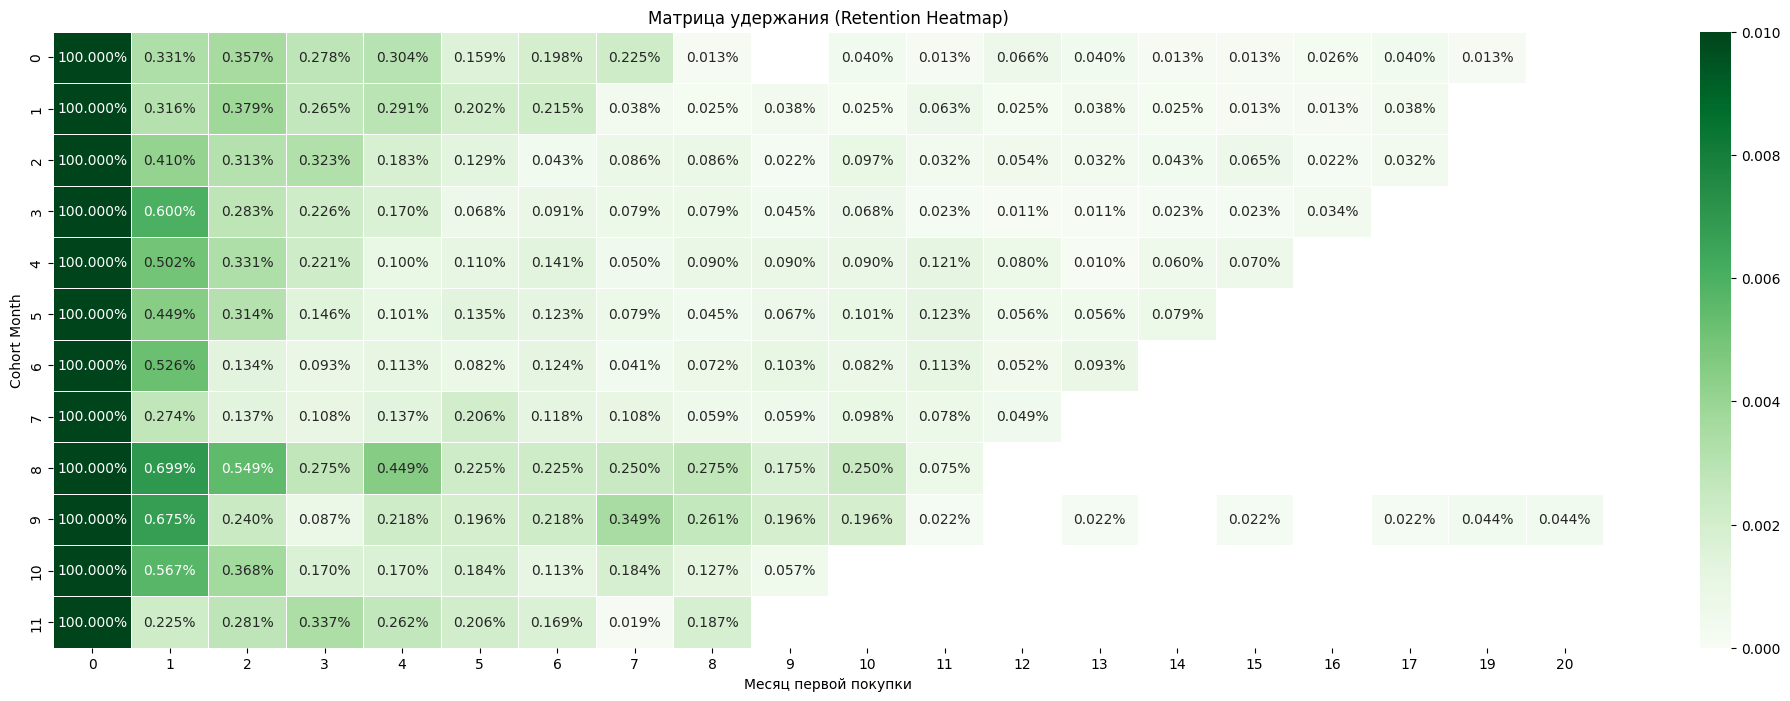

In [ ]:
'''Матрица удержания (Retention Heatmap): Визуализируйте когортную матрицу (из Лаб №3).
Используйте sns.heatmap.
Настройте cmap (цветовую палитру), чтобы высокие значения
(высокий retention) подсвечивались ярко.
Выведите значения внутри ячеек ( annot=True), отформатировав их как проценты.'''


plt.figure(figsize=(25, 8))

retention = cohort_matrix.divide(
    cohort_matrix[cohort_matrix.columns[0]],
    axis=0
)

sns.heatmap(
    retention,
    annot=True,
    fmt='.3%',
    cmap='Greens',
    vmin=0,
    vmax=0.01,
    linewidths=0.5
)

plt.title('Матрица удержания (Retention Heatmap)')

plt.xlabel('Месяц первой покупки')
plt.ylabel('Cohort Month')

plt.show()


In [ ]:
day_vs_hour = pd.read_csv('/content/drive/MyDrive/day_hour.csv')
day_vs_hour

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,390,240,642,2073,1564,446,255,419,477,890,...,1030,1084,972,1037,912,917,892,937,985,693
1,459,282,1803,1237,698,146,169,292,544,928,...,1044,1177,1019,1064,929,925,980,903,893,608
2,399,247,1771,1152,604,120,183,251,471,758,...,1002,994,1135,1019,865,866,888,1361,1530,1152
3,712,613,3175,1232,874,240,326,391,620,1210,...,1719,1713,1791,1705,1496,1603,1752,1112,1010,763
4,428,257,1010,674,327,99,133,240,498,776,...,1268,1113,1411,1282,1031,1065,1042,323,21,22
5,8,3,2,1,10,10,1,5,12,26,...,35,25,20,30,21,32,18,27,28,24
6,7,7,4,8,5,0,6,2,15,17,...,19,29,18,30,28,24,27,731,975,701


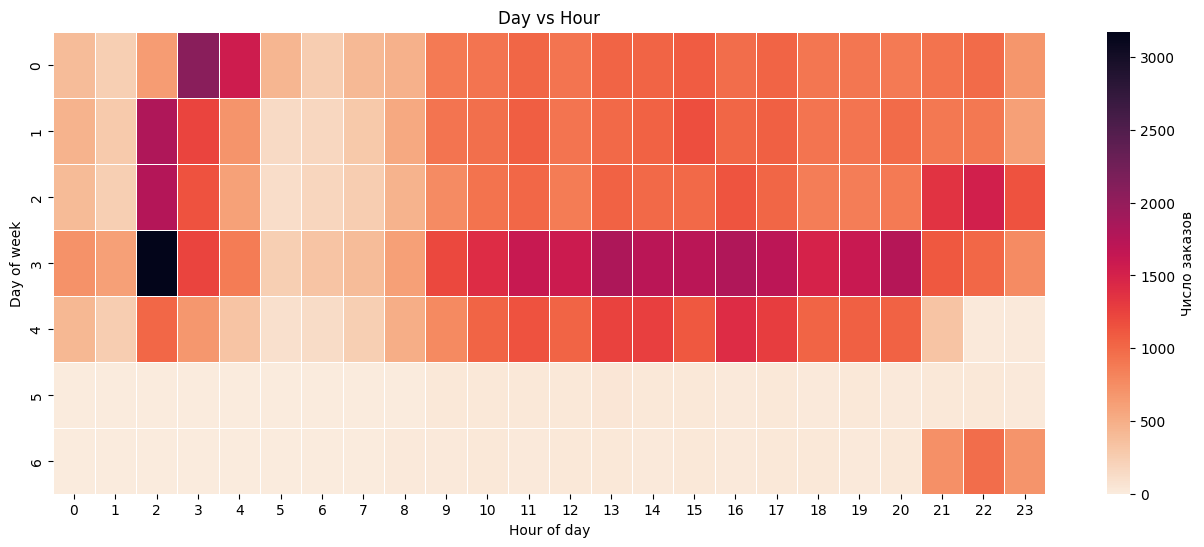

In [ ]:
'''Интрадэй-паттерн (Day vs Hour): Постройте тепловую карту покупательской активности
(из Лаб №4: День недели по вертикали, Час суток по горизонтали).
Добавьте цветовую шкалу и сделайте вывод о том,
когда логистическим системам нужно выделять максимум серверных мощностей.'''

plt.figure(figsize=(16, 6))

sns.heatmap(
    day_vs_hour,
    cmap='rocket_r',
    linewidths=0.5,
    cbar_kws={'label': 'Число заказов'}
)

plt.title('Day vs Hour')

plt.xlabel('Hour of day')
plt.ylabel('Day of week')

plt.show()

Можно заметить:


*   В основном заказы поступают в будние дни
*   Стабильный поток заказов в промежутке 8-23

Что-то необычное:



*   В четверг поступает большее количество заказов относительно других дней
*   В 2-3 часа в будние количество заказов резко увеличивается и затем падает
*   В 2 часа в четверг поступает аномальное количество заказов





# Задание 3

In [ ]:
import matplotlib.dates as mdates
revenue = pd.read_csv('/content/drive/MyDrive/revenue.csv')
anomalies = pd.read_csv('/content/drive/MyDrive/anomalies.csv')
anomalies = anomalies[anomalies['daily_revenue_y'] > 0]
revenue['index'] = pd.to_datetime(revenue['index'])

anomalies = anomalies.fillna(0)
anomalies = anomalies[anomalies['daily_revenue_x'] > 0]
anomalies

,index,daily_revenue_x,daily_revenue_y,year,revenue_ytd
32,2016-10-21,3.679142,13044.18,2016,48145.41
99,2016-12-27,5.294651,10.90,2016,49785.92
112,2017-01-09,5.292654,396.90,2017,396.90
113,2017-01-10,4.735165,806.48,2017,1203.38
114,2017-01-11,3.854902,981.90,2017,2185.28
116,2017-01-13,2.543728,803.78,2017,3308.85
117,2017-01-14,4.156045,1999.77,2017,5308.62
118,2017-01-15,3.235355,2032.08,2017,7340.70
120,2017-01-17,3.014715,2435.68,2017,10805.27
123,2017-01-20,2.964844,3343.70,2017,17391.92


In [ ]:
roll_mean = pd.read_csv('/content/drive/MyDrive/roll_mean.csv')
roll_mean['rolling_30'] = roll_mean['daily_revenue'].rolling(30, min_periods=1).mean()
revenue['index'] = pd.to_datetime(revenue['index'], errors='coerce')
roll_mean['index'] = pd.to_datetime(roll_mean['index'], errors='coerce')
anomalies['index'] = pd.to_datetime(anomalies['index'], errors='coerce')
intersection = pd.merge(
    revenue,
    roll_mean,
    on='index',
    how='inner'
)

437 index              2017-11-30 00:00:00
daily_revenue_x               4.308776
daily_revenue_y              177273.16
year                              2017
revenue_ytd                  5135947.6
Name: 437, dtype: object
486 index              2018-01-18 00:00:00
daily_revenue_x               2.613565
daily_revenue_y               80720.18
year                              2018
revenue_ytd                  476733.35
Name: 486, dtype: object
354 index              2017-09-08 00:00:00
daily_revenue_x               2.545511
daily_revenue_y               52011.86
year                              2017
revenue_ytd                 3147467.44
Name: 354, dtype: object


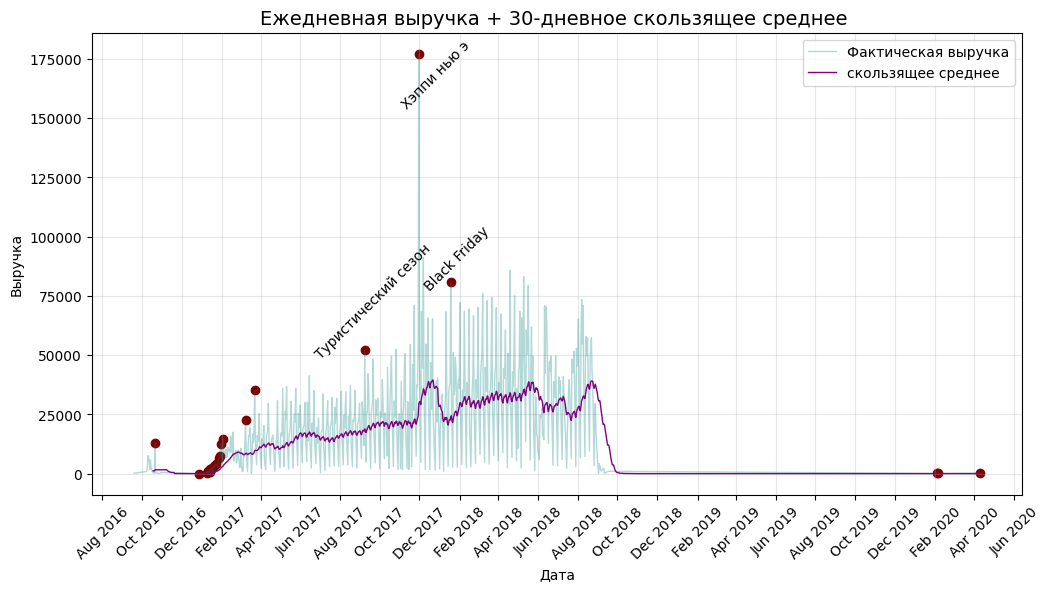

In [ ]:
''' Базовый тренд: Постройте линейный график фактической ежедневной
выручки (тонкой линией с низкой прозрачностью, alpha=0.3). '''

plt.figure(figsize=(12, 6))


rev1 = revenue.copy()
rev1 = rev1[rev1['price'] > 0]

rev1['rolling_30'] = rev1['price'].rolling(30).mean()

plt.plot(
    rev1['index'],
    rev1['price'],
    alpha=0.3,
    linewidth=1,
    label='Фактическая выручка',
    color='teal'
)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)

plt.title('Базовый тренд: Ежедневная выручка', fontsize=14)

plt.xlabel('Дата')
plt.ylabel('Выручка')

plt.legend()
plt.grid(True, alpha=0.3)

'''Сглаживание: Наложите поверх него 30-дневное скользящее среднее
(жирной линией контрастного цвета).'''

plt.plot(
    intersection['index'],
    intersection['daily_revenue'],
    alpha=1,
    linewidth=1,
    label='скользящее среднее',
    color='purple'
)

plt.title('Ежедневная выручка + 30-дневное скользящее среднее ', fontsize=14)

'''Подсветка выбросов: Используя plt.scatter, наложите поверх линейного
графика красные точки-маркеры в тех координатах (дата, выручка), где ваш
Z-score превысил порог аномальности. Добавьте текстовые аннотации ( plt.annotate)
к самым крупным выбросам (например, подпись "Black Friday").'''

plt.scatter(
    anomalies['index'],
    anomalies['daily_revenue_y'],
    color='maroon'
)

top = anomalies.nlargest(3, 'daily_revenue_y')
for idx, row in top.iterrows():
    print(idx, row)

t1 = ('2017-11-30 00:00:00', 80720.18)
t2 = ('2018-01-18 00:00:00', 177273.16)
t3 = ('2017-09-08 00:00:00', 52011.86)

plt.annotate('Black Friday', xy=(pd.to_datetime('2017-11-24') - pd.Timedelta(days=10), 80720-15000),
             xytext=(10, 20), textcoords='offset points', rotation=45,)

plt.annotate('Хэппи нью э', xy=(pd.to_datetime('2018-01-18')- pd.Timedelta(days=100), 177273-35000),
             xytext=(10, 20), textcoords='offset points', rotation=45)

plt.annotate('Туристический сезон', xy=(pd.to_datetime('2017-09-08')- pd.Timedelta(days=100), 52011-15000),
             xytext=(10, 20), textcoords='offset points', rotation=45)

plt.xlabel('Дата')
plt.ylabel('Выручка')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
review_data = pd.read_csv('/content/drive/MyDrive/review_data.csv')
review_data = pd.merge(review_data, order_reviews, on='order_id', how='left')
review_data = pd.merge(review_data, order_items, on='order_id', how='left')

review_data

,order_id,customer_id,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_working_days,estimated_delivery_time_working_days,is_delayed,...,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,6.0,12.0,False,...,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8.0,12.0,False,...,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,7.0,19.0,False,...,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,10.0,19.0,False,...,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,3.0,9.0,False,...,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114087,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,16.0,18.0,False,...,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01,1.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10
114088,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,18.0,22.0,False,...,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57,1.0,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02
114089,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,13.0,28.0,False,...,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,1.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59
114090,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,13.0,28.0,False,...,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


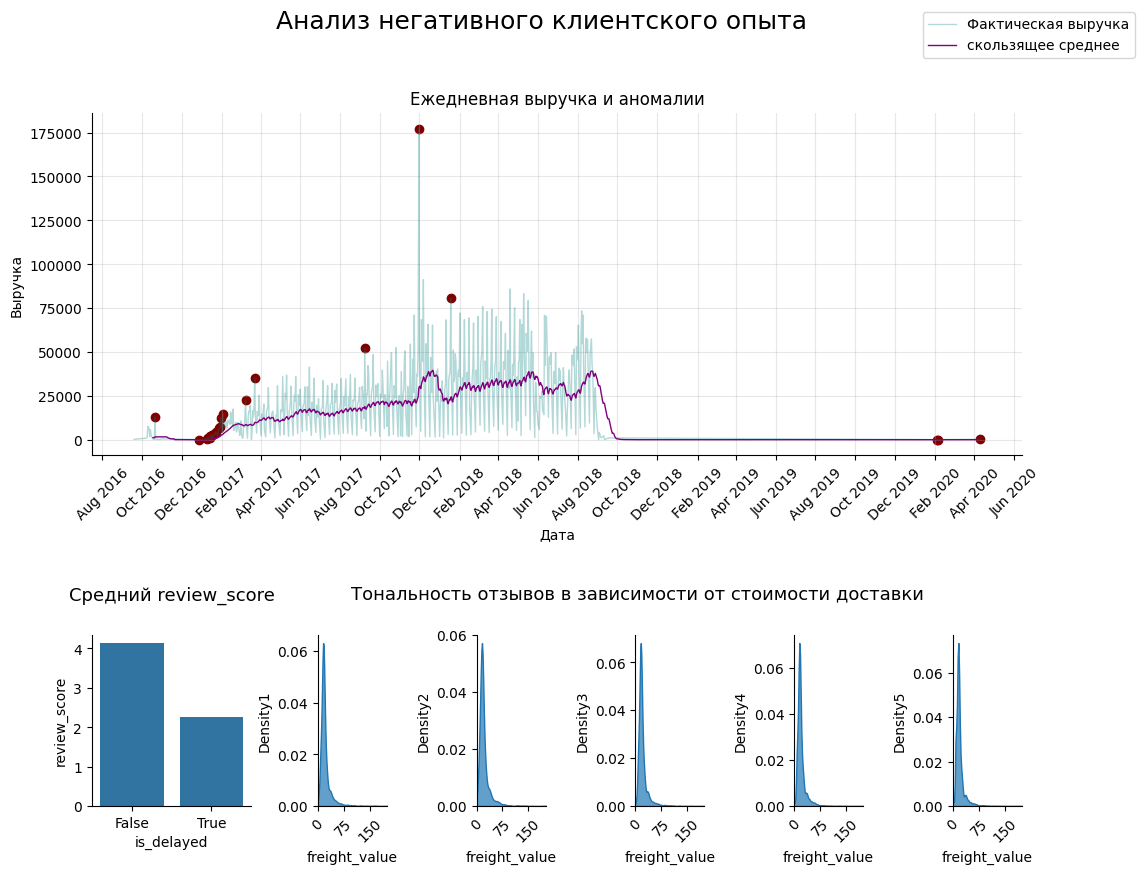

In [ ]:
'''Архитектура GridSpec: Используя matplotlib.gridspec,
создайте полотно, где верхний график занимает всю ширину
(1 ряд, 2 колонки), а под ним располагаются два графика поменьше.'''

import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator

fig = plt.figure(figsize=(12, 9), constrained_layout=True)

gs = gridspec.GridSpec(
    2,
    3,
    figure=fig,
    height_ratios=[2, 1],
    width_ratios=[1, 2, 2],
    hspace=0.7,
    wspace=0.25
)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])

'''Наполнение'''
# Верхний (широкий): Временной ряд с красными точками аномальных задержек доставки

ax1.plot(
    rev1['index'],
    rev1['price'],
    alpha=0.3,
    linewidth=1,
    label='Фактическая выручка',
    color='teal'
)

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax1.plot(
    intersection['index'],
    intersection['daily_revenue'],
    alpha=1,
    linewidth=1,
    label='скользящее среднее',
    color='purple'
)

ax1.scatter(
    anomalies['index'],
    anomalies['daily_revenue_y'],
    color='maroon'
)
ax1.tick_params(axis='x', rotation=45)

ax1.set_title('Ежедневная выручка и аномалии')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Выручка')

ax1.grid(True, alpha=0.3)


# Нижний левый: График распределения (bar plot) средних оценок в зависимости от факта нарушения SLA
sla_reviews = review_data.groupby('is_delayed')['review_score'].mean().reset_index()

sns.barplot(
    data=sla_reviews,
    x='is_delayed',
    y='review_score',
    ax=ax2
)
ax2.set_title('Средний review_score',pad=25,fontsize=13)

# Нижний правый: Фасетный график, показывающий, как меняется тональность отзывов в зависимости от стоимости доставки

scores = sorted(
    review_data['review_score']
    .dropna()
    .unique()
)
inner_gs = gridspec.GridSpecFromSubplotSpec(
    1,
    5,
    subplot_spec=gs[1, 1:],
    wspace=1.3
)

for i, score in enumerate(scores):

    ax = fig.add_subplot(inner_gs[i])
    subset = review_data[review_data['review_score'] == score]

    sns.kdeplot(
        data=subset,
        x='freight_value',
        fill=True,
        alpha=0.7,
        ax=ax
    )

    ax.xaxis.set_major_locator(MultipleLocator(75))
    plt.xticks(rotation=45)

    ax.set_xlim(0, 200)
    ax.set_ylabel('Density'+f'{int(score)}')

fig.text(
    0.58,
    0.34,
    'Тональность отзывов в зависимости от стоимости доставки',
    ha='center',
    fontsize=13
)



'''Эстетика: Удалите верхние и правые рамки у всех графиков
( sns.despine()), настройте общую легенду, чтобы она не перекрывала
данные, и дайте дашборду глобальный заголовок ( fig.suptitle).'''

sns.despine()
fig.suptitle('Анализ негативного клиентского опыта', fontsize=18)

handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper right',
    bbox_to_anchor=(1,1)
)
plt.show()

Аномальные периоды выручки можно наблюдать с резкими скачками нагрузки на доставку.

При нарушении SLA средний review_score снижается,
что указывает на сильную зависимость оценки клиентов
от скорости доставки.

Также видно, стоимость доставки распределена схожим образом для всех групп отзывов, однако дорогая доставка чаще встречается среди негативных оценок. Это указывает на то, что высокая цена доставки усиливает недовольство клиентов.